# 1. Formulación del problema

Se considera la ecuación de calor unidimensional:

∂u/∂t = α ∂²u/∂x²

donde:
- u(x,t): temperatura
- α: coeficiente de difusión térmica

El objetivo es aproximar la solución u(x,t) mediante una red neuronal profunda 
û(x,t; θ), entrenada de tal forma que:

1. Satisfaga la ecuación diferencial (residuo ≈ 0)
2. Cumpla la condición inicial
3. Cumpla las condiciones de frontera

Este enfoque corresponde a una **Physics-Informed Neural Network (PINN)**.

In [1]:
import torch
import numpy as np
import torch.nn as nn

# 2. Residuo de la ecuación diferencial

Para entrenar la red, se define el residuo de la EDP:

R(x,t) = ∂û/∂t − α ∂²û/∂x²

Este residuo debe ser cercano a cero si la red aproxima correctamente la solución.

Las derivadas se calculan mediante **diferenciación automática (autograd)**,
lo que permite obtener derivadas exactas (hasta precisión de máquina).

In [2]:
def pde_residual(model, x, t, alpha=0.01):
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    # Derivada temporal
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]

    # Derivadas espaciales
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t - alpha * u_xx

# 3. Construcción de los datos de entrenamiento

El entrenamiento de la PINN requiere tres conjuntos de datos:

## 3.1 Condición inicial (IC)
Se impone:
u(x,0) = sin(πx)

## 3.2 Condiciones de frontera (BC)
u(0,t) = 0,   u(L,t) = 0

## 3.3 Puntos de colocación (PDE)
Puntos aleatorios en el dominio donde se evalúa el residuo.

Estos tres componentes permiten incorporar la física del problema en la función de pérdida.


# Construcción de los conjuntos de entrenamiento en una PINN

Este bloque de código define los parámetros físicos del problema y construye los conjuntos de datos necesarios para entrenar una **Physics-Informed Neural Network (PINN)** aplicada a la ecuación de calor.

--

## 1. Parámetros físicos del problema

* **L**: Longitud de la barra. Define el dominio espacial:

  $$
  x \in [0, L]
  $$

* **T_max**: Tiempo máximo de simulación. Define el dominio temporal:

  $$
  t \in [0, T]
  $$

* **alpha (α)**: Difusividad térmica. Controla la velocidad de propagación del calor:

  * α pequeño → difusión lenta
  * α grande → difusión rápida

--

## 2. Cantidad de puntos de entrenamiento

```python
N_ic = 500
N_bc = 500
N_pde = 10000
```

En una PINN no se utilizan datos experimentales tradicionales. En su lugar, se construyen puntos en el dominio donde se imponen restricciones físicas.

* **N_ic**: número de puntos para la condición inicial
* **N_bc**: número de puntos para las condiciones de frontera
* **N_pde**: número de puntos internos para evaluar la ecuación diferencial

⚠️ Observación importante:

$$
N_{pde} \gg N_{ic}, N_{bc}
$$

Esto se debe a que la ecuación diferencial debe cumplirse en todo el dominio.

--

## 3. Condición inicial (Initial Condition, IC)

```python
x_ic = torch.linspace(0, L, N_ic).view(-1, 1).float()
t_ic = torch.zeros(N_ic, 1).float()
u_ic = torch.sin(np.pi * x_ic / L).float()
```

### 3.1 Puntos espaciales

```python
torch.linspace(0, L, N_ic)
```

Genera ( N_{ic} ) puntos equiespaciados en el intervalo:

$$
x \in [0, L]
$$

Luego:

```python
.view(-1, 1)
```

Convierte el vector en una matriz columna:

$$
(500,) \rightarrow (500,1)
$$

Esto es necesario para alimentar correctamente la red neuronal.

--
### 3.2 Tiempo fijo

```python
t_ic = torch.zeros(N_ic, 1)
```

Todos los puntos tienen:

$$
t = 0
$$

porque representan la condición inicial.

--

### 3.3 Valor de la solución

```python
u_ic = sin(\pi x / L)
```

Se impone:

$$
u(x,0) = \sin\left(\frac{\pi x}{L}\right)
$$

💡 Interpretación:

Se está enseñando a la red cómo es la solución en el instante inicial.

--

## 4. Condiciones de frontera (Boundary Conditions, BC)

```python
t_bc = torch.linspace(0, T_max, N_bc // 2).view(-1, 1).float()
```

Se generan puntos en el tiempo:

$$
t \in [0, T]
$$

Solo la mitad porque se usarán dos fronteras.

--

### 4.1 Frontera izquierda

```python
x_bc_left = torch.zeros(N_bc // 2, 1)
```

Representa:

$$
x = 0
$$

--

### 4.2 Frontera derecha

```python
x_bc_right = torch.full((N_bc // 2, 1), L)
```

Representa:

$$
x = L
$$

--

### 4.3 Unión de fronteras

```python
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_total = torch.cat([t_bc, t_bc], dim=0)
```

Se construyen todos los puntos de frontera:

$$
(x,t) = (0,t) \cup (L,t)
$$

--

### 4.4 Interpretación física

Se imponen condiciones de Dirichlet homogéneas:

$$
u(0,t) = 0, \quad u(L,t) = 0
$$

💡 Importante:

La red no conoce estas condiciones de forma implícita. Se le imponen mediante la función de pérdida.

--

## 5. Puntos de colocación (PDE)

```python
x_pde = torch.rand(N_pde, 1) * L
t_pde = torch.rand(N_pde, 1) * T_max
```

Se generan puntos aleatorios dentro del dominio:

$$
x \sim U(0, L), \quad t \sim U(0, T)
$$

--

### 5.1 ¿Por qué aleatorios?

A diferencia de métodos clásicos como diferencias finitas, no se usa una malla regular.

Se emplea un muestreo tipo Monte Carlo para cubrir el dominio.

--

### 5.2 Propósito

En estos puntos se evalúa el residuo de la ecuación:

$$
\frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2} = 0
$$

La red se entrena para que este residuo sea cercano a cero.

--

## 6. Interpretación global

Este bloque construye tres conjuntos fundamentales:

### 6.1 Condición inicial (IC)

$$
(x,0) \rightarrow u(x,0)
$$

Define el estado inicial del sistema.

--

### 6.2 Condiciones de frontera (BC)

$$
(0,t), (L,t) \rightarrow u = 0
$$

Define el comportamiento en los extremos.

--

### 6.3 Ecuación diferencial (PDE)

$$
(x,t) \rightarrow \text{cumplir la ecuación}
$$

Impone la física del problema en todo el dominio.

--

## 7. Idea clave de las PINNs

A diferencia del aprendizaje supervisado tradicional:

* No se entrena con datos observados
* Se entrena con **leyes físicas**

La red neuronal aprende una función que:

* Satisface la ecuación diferencial
* Cumple condiciones iniciales
* Cumple condiciones de frontera


In [9]:
L = 1.0
T_max = 1.0
alpha = 0.01

N_ic = 500
N_bc = 500
N_pde = 10000

# Condición inicial
x_ic = torch.linspace(0, L, N_ic).view(-1, 1).float()
t_ic = torch.zeros(N_ic, 1).float()
u_ic = torch.sin(np.pi * x_ic / L).float()

# Condiciones de frontera
t_bc = torch.linspace(0, T_max, N_bc // 2).view(-1, 1).float()
x_bc_left = torch.zeros(N_bc // 2, 1).float()
x_bc_right = torch.full((N_bc // 2, 1), L).float()

x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_total = torch.cat([t_bc, t_bc], dim=0)

# Puntos PDE
x_pde = torch.rand(N_pde, 1) * L
t_pde = torch.rand(N_pde, 1) * T_max

# 4. Arquitectura de la PINN

Se utiliza una red neuronal totalmente conectada (MLP) con:

- Entrada: (x, t)
- 3 capas ocultas de 32 neuronas
- Activación: tanh
- Salida: û(x,t)

La función tanh se utiliza porque es suave (C∞), lo cual es crucial
para calcular derivadas de orden superior.

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN()

# 5. Función de pérdida

La función de pérdida total es:

L = L_PDE + L_IC + L_BC

donde:

- L_PDE: residuo de la ecuación
- L_IC: error en condición inicial
- L_BC: error en condiciones de frontera

Esto fuerza a la red a respetar simultáneamente la física y las condiciones del problema.

In [5]:
def closure():
    optimizer_adam.zero_grad()
    optimizer_lbfgs.zero_grad()

    mse_pde = torch.mean(pde_residual(model, x_pde, t_pde)**2)
    mse_ic = torch.mean((model(x_ic, t_ic) - u_ic)**2)
    mse_bc = torch.mean(model(x_bc, t_bc_total)**2)

    loss = mse_pde + mse_ic + mse_bc
    loss.backward()
    return loss

# 6. Estrategia de optimización

Se emplea una estrategia en dos fases:

## Fase 1: Adam
Permite una convergencia rápida inicial.

## Fase 2: LBFGS
Optimización de segundo orden para refinamiento fino.

El uso de LBFGS requiere una función "closure", ya que evalúa múltiples
veces la función de pérdida dentro de cada iteración.

In [6]:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=50000,
    tolerance_grad=1e-7,
    line_search_fn="strong_wolfe"
)

# Fase 1
for i in range(2000):
    optimizer_adam.step(closure)

# Fase 2
optimizer_lbfgs.step(closure)

tensor(9.2251e-06, grad_fn=<AddBackward0>)

# 7. Validación del modelo

Se compara la predicción de la red con la solución analítica:

u*(x,t) = exp(-απ²t) sin(πx)

Se evalúa el error en norma infinito (L∞).

In [7]:
def exacta(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x / L)

x_test = torch.linspace(0, L, 100).view(-1, 1)
t_test = torch.full_like(x_test, 1.0)

u_pred = model(x_test, t_test).detach().numpy()
u_true = exacta(x_test.numpy(), t_test.numpy())

error_inf = np.max(np.abs(u_pred - u_true))
print(error_inf)

0.0013257861


In [11]:
print("Fase 1: Optimizando con Adam...")
for i in range(2000):
    optimizer_adam.step(closure)
    if i % 500 == 0:
        print(f"Iteración {i}, Loss: {closure().item():.2e}")

print("\nFase 2: Refinando con LBFGS...")
optimizer_lbfgs.step(closure)
print(f"Loss Final: {closure().item():.2e}")

Fase 1: Optimizando con Adam...
Iteración 0, Loss: 7.71e-04
Iteración 500, Loss: 7.68e-07
Iteración 1000, Loss: 5.98e-07
Iteración 1500, Loss: 5.30e-07

Fase 2: Refinando con LBFGS...
Loss Final: 5.06e-07


In [12]:
def exacta(x, t):
    # u*(x, t) = exp(-alpha * pi^2 * t) * sin(pi * x / L) 
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x / L)

# Evaluación en t = 1.0
x_test = torch.linspace(0, L, 100).view(-1, 1)
t_test = torch.full_like(x_test, 1.0)
u_pred = model(x_test, t_test).detach().numpy()
u_true = exacta(x_test.numpy(), t_test.numpy())

error_inf = np.max(np.abs(u_pred - u_true))
print(f"\nError L-inf en t=1.0s: {error_inf:.2e}")


Error L-inf en t=1.0s: 1.45e-04


# 8. Análisis de resultados

Se obtiene:

- Loss ≈ 10⁻⁷
- Error L∞ ≈ 10⁻³

## Interpretación

La pérdida mide el cumplimiento de la física en puntos de entrenamiento,
mientras que el error mide la discrepancia global.

La diferencia entre ambos valores es normal y se debe a:

- Distribución de puntos de entrenamiento
- Generalización de la red
- Balance entre términos de la pérdida

## Conclusión

La PINN logra una precisión comparable al método de diferencias finitas,
capturando correctamente la dinámica de difusión del calor.

# 9. Visualización de resultados

Se comparan:

- Solución exacta
- Predicción PINN
- Error absoluto

También se analizan perfiles de temperatura en distintos tiempos.

<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_26955/4232597746.py:32: SyntaxWarning: invalid escape sequence '\h'
  ax[1].set_title("Predicción PINN $\hat{u}(x, t)$")
/tmp/ipykernel_26955/4232597746.py:39: SyntaxWarning: invalid escape sequence '\h'
  ax[2].set_title("Error Absoluto $|u^* - \hat{u}|$")


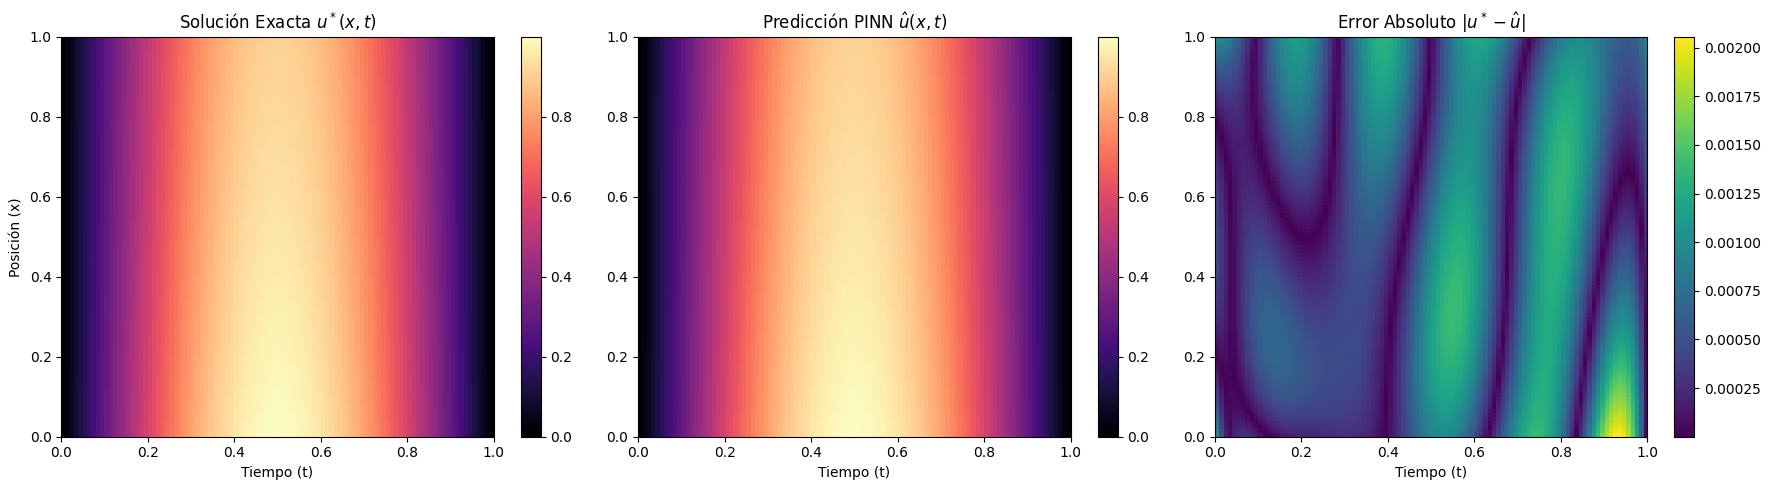

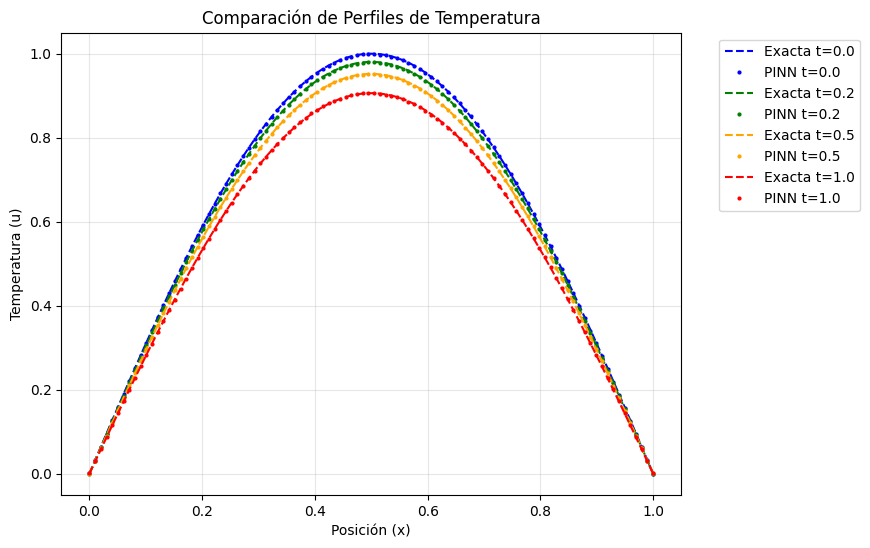

In [8]:
import matplotlib.pyplot as plt
def plot_results(model, L=1.0, T=1.0, alpha=0.01):

    # 1. Generar malla para el mapa de calor
    x = np.linspace(0, L, 100)
    t = np.linspace(0, T, 100)
    X, T_grid = np.meshgrid(x, t)
    
    # Preparar datos para la red (aplanar y convertir a tensor)
    x_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
    t_flat = torch.tensor(T_grid.flatten(), dtype=torch.float32).view(-1, 1)
    
    # Predicción de la PINN
    with torch.no_grad():
        u_pred = model(x_flat, t_flat).numpy().reshape(100, 100)
    
    # Solución Analítica Exacta [cite: 57]
    u_exact = np.exp(-alpha * np.pi**2 * T_grid) * np.sin(np.pi * X / L)
    
    # 2. Crear la figura
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # Subplot 1: Solución Exacta
    im0 = ax[0].imshow(u_exact, extent=[0, T, 0, L], origin='lower', aspect='auto', cmap='magma')
    ax[0].set_title("Solución Exacta $u^*(x, t)$")
    ax[0].set_xlabel("Tiempo (t)")
    ax[0].set_ylabel("Posición (x)")
    fig.colorbar(im0, ax=ax[0])
    
    # Subplot 2: Predicción PINN
    im1 = ax[1].imshow(u_pred, extent=[0, T, 0, L], origin='lower', aspect='auto', cmap='magma')
    ax[1].set_title("Predicción PINN $\hat{u}(x, t)$")
    ax[1].set_xlabel("Tiempo (t)")
    fig.colorbar(im1, ax=ax[1])
    
    # Subplot 3: Error Absoluto
    error = np.abs(u_exact - u_pred)
    im2 = ax[2].imshow(error, extent=[0, T, 0, L], origin='lower', aspect='auto', cmap='viridis')
    ax[2].set_title("Error Absoluto $|u^* - \hat{u}|$")
    ax[2].set_xlabel("Tiempo (t)")
    fig.colorbar(im2, ax=ax[2])
    
    plt.tight_layout()
    plt.show()

    # 3. Gráfica de perfiles temporales (Cortes en t)
    plt.figure(figsize=(8, 6))
    tiempos = [0.0, 0.2, 0.5, 1.0]
    colors = ['blue', 'green', 'orange', 'red']
    
    for i, t_val in enumerate(tiempos):
        # Exacta
        u_e = np.exp(-alpha * np.pi**2 * t_val) * np.sin(np.pi * x / L)
        # PINN
        t_tensor = torch.full((100, 1), t_val, dtype=torch.float32)
        x_tensor = torch.tensor(x, dtype=torch.float32).view(-1, 1)
        u_p = model(x_tensor, t_tensor).detach().numpy()
        
        plt.plot(x, u_e, label=f'Exacta t={t_val}', color=colors[i], linestyle='--')
        plt.plot(x, u_p, 'o', markersize=2, color=colors[i], label=f'PINN t={t_val}')

    plt.title("Comparación de Perfiles de Temperatura")
    plt.xlabel("Posición (x)")
    plt.ylabel("Temperatura (u)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

# Ejecutar la función
plot_results(model)